### **1. Introduction**

This notebook explains soil zones generated using K-Means clustering. Since clustering is unsupervised, explainability is achieved through post-hoc analytical methods rather than prediction.

Objectives:
1. Describe what defines each soil zone
2. Validate cluster quality
3. Extract human readable decision rules
4. Identify internal variations

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score, silhouette_samples, silhouette_score
from sklearn.ensemble import RandomForestClassifier

import shap

### **2. Load Clustered Dataset**

In [2]:
df = pd.read_csv("../outputs/soil_clusters.csv")

features = [
    "taw", 
    "organic_carbon", 
    "cec", 
    "ph", 
    "sand_pct"
    ]

X = df[features]
y = df["cluster"]

print("Samples:", len(df))
print("Clusters:", sorted(y.unique()))
print("\nCluster distribution:")
print(y.value_counts().sort_index())

Samples: 3422
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Cluster distribution:
cluster
0     353
1    1305
2     524
3    1240
Name: count, dtype: int64


### **3. Scale Features for Interpretability**

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=features)

### **4. Centroid Deviation**

#### **Compute Deviations**

In [4]:
global_mean = X_scaled_df.mean()

cluster_means = X_scaled_df.groupby(y).mean()
deviation = cluster_means - global_mean

deviation

,taw,organic_carbon,cec,ph,sand_pct
cluster,,,,,
0,1.795962,-1.101721,0.428829,0.967773,0.422534
1,-0.599355,-0.600889,-1.201932,-0.355352,-0.122376
2,-0.932307,-0.360482,0.560653,1.589571,1.560045
3,0.513478,1.098355,0.905937,-0.573246,-0.650740


#### **Visualize Cluster Characteristics**

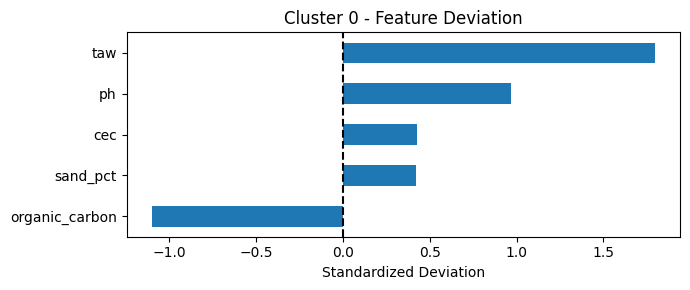

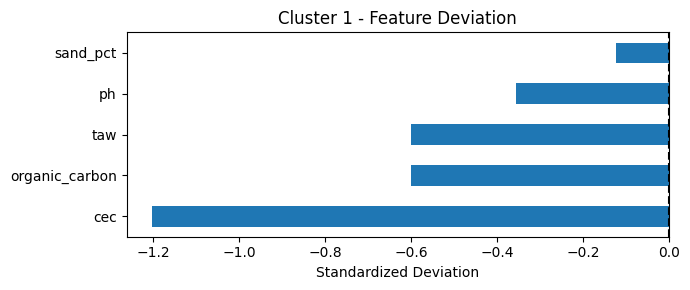

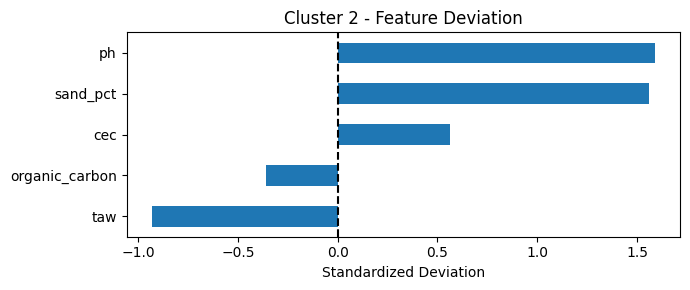

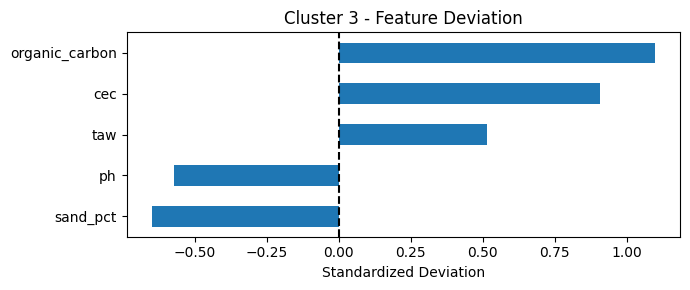

In [5]:
for c in deviation.index:
    plt.figure(figsize=(7, 3))
    deviation.loc[c].sort_values().plot(kind="barh")
    plt.axvline(0, color="black", linestyle="--")
    plt.title(f"Cluster {c} - Feature Deviation")
    plt.xlabel("Standardized Deviation")
    plt.tight_layout()
    plt.show()

The above values represent standardized deviations from the global average soil condition. The magnitude of the absolute value reflects how strongly a given feature characterizes the cluster, with larger absolute values representing more defining soil properties.
$$
\begin{array}{c l}
0 & \text{=  Global average soil} \\
+ & \text{=  Higher than average} \\
- & \text{=  Lower than average}
\end{array}
$$

#### **Cluster 0**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +1.80 & \text{Extremely high water holding} \\
\text{Organic Carbon} & -1.10 & \text{Very low organic matter} \\
\text{CEC} & +0.43 & \text{Moderate nutrient holding} \\
\text{pH} & +0.97 & \text{Moderately less acidic} \\
\text{Sand \%} & +0.42 & \text{Moderately sandy}
\end{array}
$$

#### **Cluster 1**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.60 & \text{Low water holding} \\
\text{Organic Carbon} & -0.60 & \text{Low organic matter} \\
\text{CEC} & -1.20 & \text{Very poor nutrient holding} \\
\text{pH} & -0.36 & \text{Acidic} \\
\text{Sand \%} & -0.12 & \text{Near average texture}
\end{array}
$$

#### **Cluster 2**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & -0.93 & \text{Very low water holding} \\
\text{Organic Carbon} & -0.36 & \text{Slightly low OC} \\
\text{CEC} & +0.56 & \text{Moderate nutrient holding} \\
\text{pH} & +1.59 & \text{Highest pH} \\
\text{Sand \%} & +1.56 & \text{Extremely sandy}
\end{array}
$$

#### **Cluster 3**
$$
\begin{array}{l c l}
\textbf{Feature} & \textbf{Deviation} & \textbf{Meaning} \\
\hline
\text{TAW} & +0.51 & \text{Good water holding} \\
\text{Organic Carbon} & +1.10 & \text{Very high OC} \\
\text{CEC} & +0.91 & \text{High nutrient holding} \\
\text{pH} & -0.57 & \text{Acidic} \\
\text{Sand \%} & -0.65 & \text{Fine textured}
\end{array}
$$

### **5. Surrogate Decision Tree**

#### **Train Decision Tree Surrogate (Primary Explainer)**

In [19]:
dt = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=50,
    random_state=42
)

dt.fit(X, y)

fidelity = accuracy_score(y, dt.predict(X))
print("Surrogate fidelity:", round(fidelity, 3))

Surrogate fidelity: 0.987


The surrogate Decision Tree achieved a fidelity score (accuracy) of 98.7% relative to the K-Means assignments. In the context of Explainable AI (XAI), this high level of accuracy indicates that the simplified tree model is a highly reliable proxy for the underlying clustering logic. Furthermore, reaching this accuracy with a shallow depth of 3 demonstrates that the soil zones are distinct and well separated by a few dominant physical and chemical properties. This minimizes the explanation gap, ensuring that the decision rules derived from the tree (such as thresholds for TAW or Organic Carbon) truthfully represent the boundaries of each soil cluster without overcomplicating the model.

#### **Vizualize Rules**

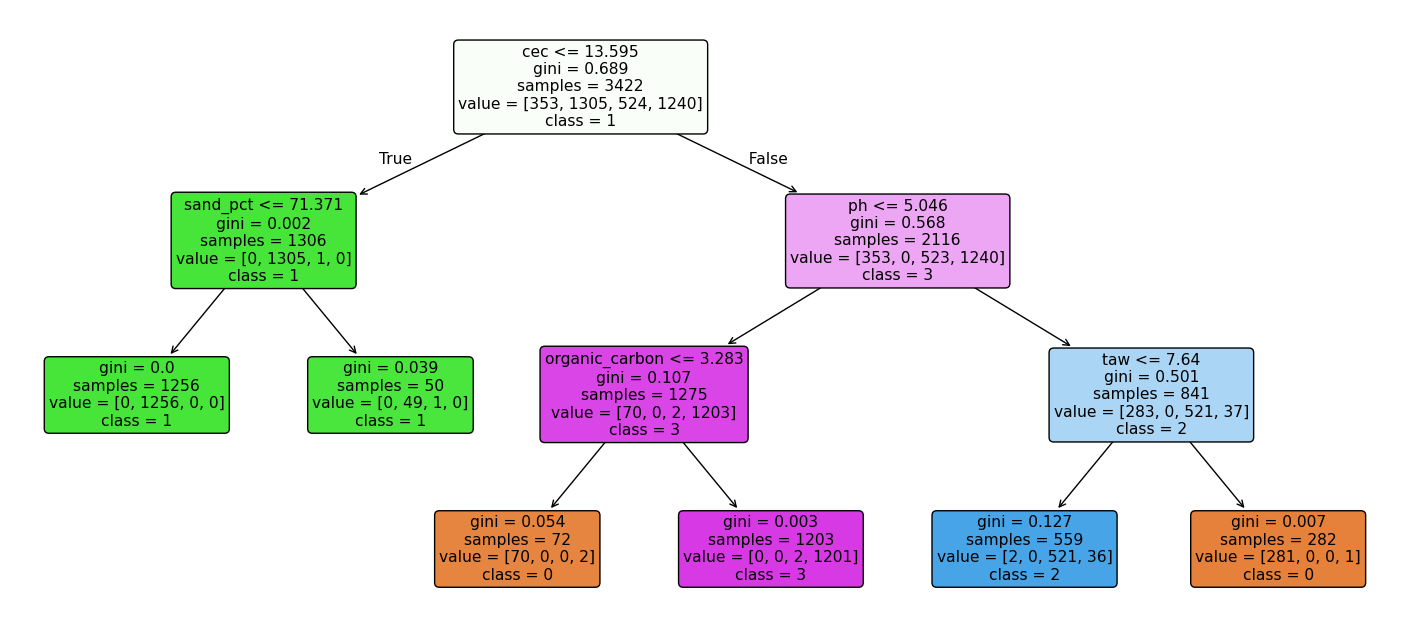

In [20]:
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=features,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True
)
plt.show()

In [21]:
rules = export_text(dt, feature_names=features)
print(rules)

|--- cec <= 13.59
|   |--- sand_pct <= 71.37
|   |   |--- class: 1
|   |--- sand_pct >  71.37
|   |   |--- class: 1
|--- cec >  13.59
|   |--- ph <= 5.05
|   |   |--- organic_carbon <= 3.28
|   |   |   |--- class: 0
|   |   |--- organic_carbon >  3.28
|   |   |   |--- class: 3
|   |--- ph >  5.05
|   |   |--- taw <= 7.64
|   |   |   |--- class: 2
|   |   |--- taw >  7.64
|   |   |   |--- class: 0



In [22]:
# Validate whether Cluster 0 pH-based split is meaningful

cluster_id = 0
threshold = df[df["cluster"] == cluster_id]["ph"].median()

group_low = df[(df["cluster"] == cluster_id) & (df["ph"] <= threshold)]
group_high = df[(df["cluster"] == cluster_id) & (df["ph"] > threshold)]

summary = pd.DataFrame({
    "Low_pH_Subgroup": group_low[features].mean(),
    "High_pH_Subgroup": group_high[features].mean(),
    "Absolute_Difference": (
        group_high[features].mean() - group_low[features].mean()
    ).abs()
})

summary

,Low_pH_Subgroup,High_pH_Subgroup,Absolute_Difference
taw,8.896300,8.753461,0.142839
organic_carbon,3.072083,2.739027,0.333056
cec,17.439899,15.836311,1.603588
ph,5.051771,5.327937,0.276166
sand_pct,66.473359,74.204530,7.731171


Although the surrogate decision tree introduced a split on soil pH prior to final cluster assignment, samples belonging to Cluster 0 appeared on both sides of the pH threshold. This indicated potential conditional heterogeneity within Cluster 0 and motivated further validation. Subgroup means were therefore compared to evaluate whether the pH split represented a meaningful sub zone. The observed pH difference between the two conditional groups $(\approx 0.27)$ was below agronomic relevance thresholds. Although the sand content difference between the two groups was moderate $(\approx 7.7\%)$, sand was not a splitting variable along the Cluster 0 decision paths in the surrogate tree. The observed difference thus reflects a secondary effect induced by splits driven by CEC, pH, and TAW rather than an independent driver of soil zone differentiation. Consequently, the pH-based split was interpreted as decision routing within the surrogate model rather than evidence of a true sub zone.

### **6. SHAP**

#### **Random Forest (Secondary Explainer)**

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42
)

rf.fit(X, y)
print("RF surrogate fidelity:", accuracy_score(y, rf.predict(X)))

RF surrogate fidelity: 0.9964932787843367


#### **SHAP Global Importance**

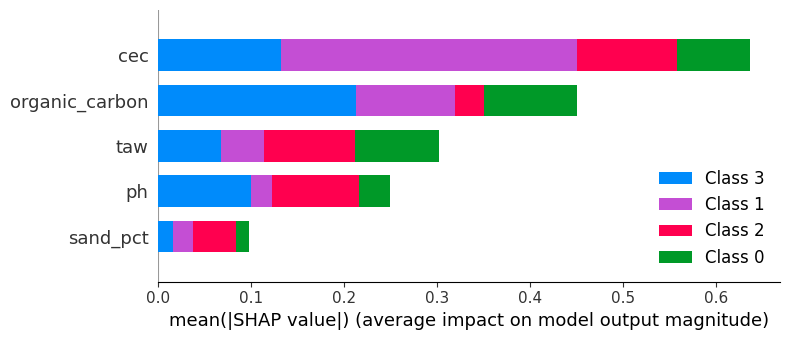

In [32]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    plot_type="bar"
)